In [1]:
import matplotlib as mpl
import seaborn as sns
import importlib

# Seaborn theme
sns.set_theme(
    style="ticks",        # "white", "whitegrid", "ticks", "darkgrid"
    context="paper",       # notebook, paper, talk, poster
    palette="deep"
)

# Your publication formatting
mpl.rcParams.update({

    # Fonts
    "font.family": "Arial",
    "font.size": 14,

    # Figure titles
    "figure.titlesize": 34,
    "figure.titleweight": "bold",

    # Axes titles/labels
    "axes.titlesize": 14,
    "axes.labelsize": 14,

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,

    # Lines & markers
    "lines.linewidth": 3,
    "lines.markersize": 8,

    # Axes
    "axes.linewidth": 2,

    # Ticks
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    # Grid
    "grid.linewidth": 1,
    "grid.alpha": 0.3,

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Editable vector graphics
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Supplement — Fixed receptor number, kinetic robustness, and height controls

Analyzes the three mechanistic-control datasets that test receptor-number confounding, kinetic generality, and correlation with distance to the escape plane.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "analysis_tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis_tools.manuscript_escape_analysis import (
    classical_occupancy, condition_statistics, discover_runs,
    load_receptor_summaries, occupancy_from_bound_time,
    replicate_survival_curves, save_figure, summarize_replicates,
)

SAVE_FIGURES = False
FIGURE_ROOT = PROJECT_ROOT / "analysis_tools" / "manuscript_panels"


In [3]:
FIXED_ROOT="/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_supp_fixed_receptor_count"
KINETIC_ROOT="/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_supp_kinetic_robustness"
HEIGHT_ROOT="/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_supp_sinusoidal_height_control"
fixed=summarize_replicates(discover_runs(FIXED_ROOT)); kinetic=summarize_replicates(discover_runs(KINETIC_ROOT)); height=summarize_replicates(discover_runs(HEIGHT_ROOT))
fixed["curvature_nm_inv"]=fixed.curvature_m_inv*1e-9
display(fixed.groupby("condition_label").n_receptors.agg(["min","mean","max"]))


,min,mean,max
condition_label,,,
R100nm__N300,300,300.0,300
R200nm__N300,300,300.0,300
R49p5nm__N300,300,300.0,300
R65nm__N300,300,300.0,300
planar__N300,300,300.0,300


## 1. Fixed total receptor number


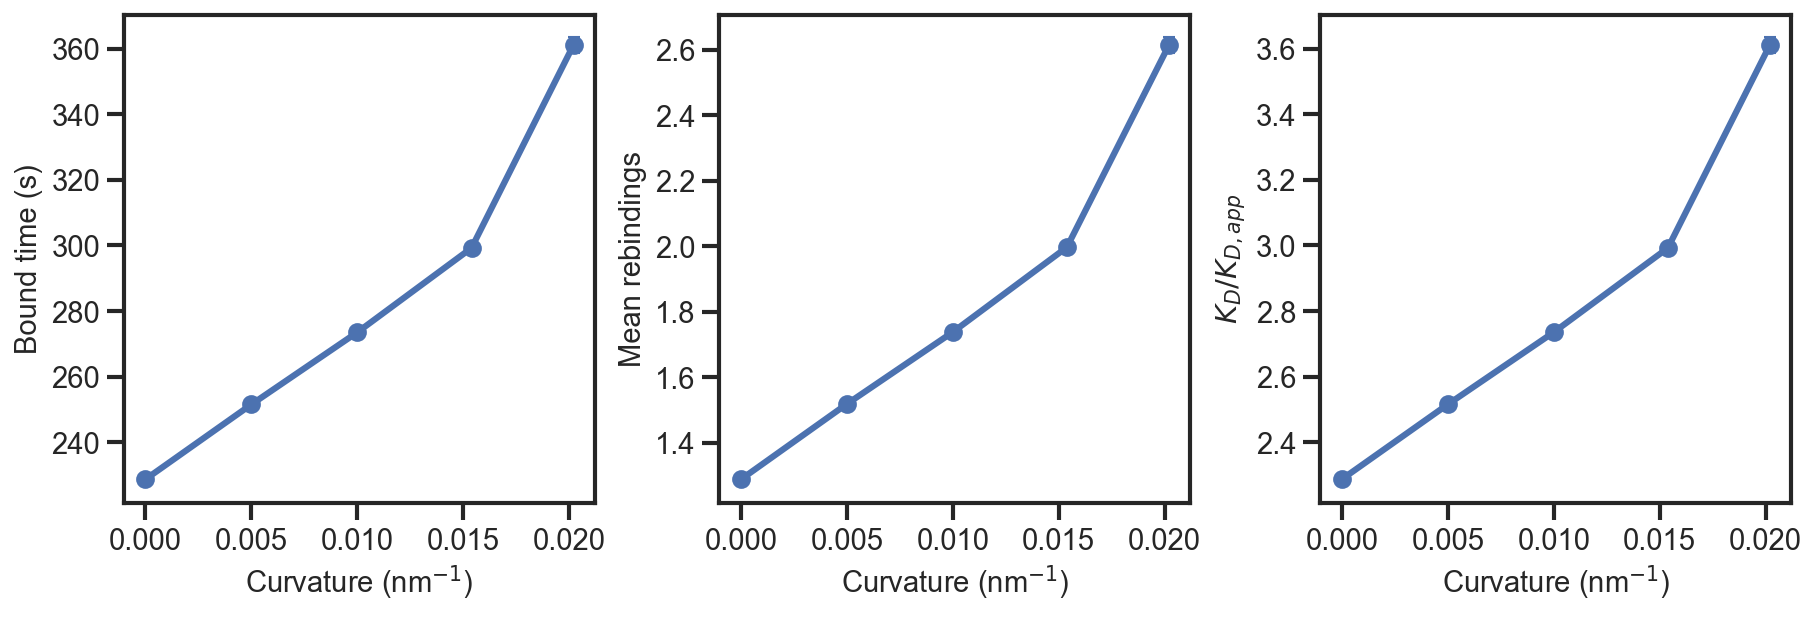

In [7]:
stats=condition_statistics(fixed,["curvature_nm_inv"],["mean_bound_time_s","mean_rebindings","affinity_shift_fold"]).sort_values("curvature_nm_inv")
fig,axes=plt.subplots(1,3,figsize=(12,4),constrained_layout=True)
for ax,metric,label in zip(axes,["mean_bound_time_s","mean_rebindings","affinity_shift_fold"],["Bound time (s)","Mean rebindings",r"$K_D/K_{D,app}$"]):
 ax.errorbar(stats.curvature_nm_inv,stats[f"{metric}_mean"],yerr=stats[f"{metric}_sem"],marker="o",capsize=3); ax.set(xlabel=r"Curvature (nm$^{-1}$)",ylabel=label)
if SAVE_FIGURES: save_figure(fig,FIGURE_ROOT,"supp_fixed_receptor_number")
plt.show()


## 2. Kinetic robustness


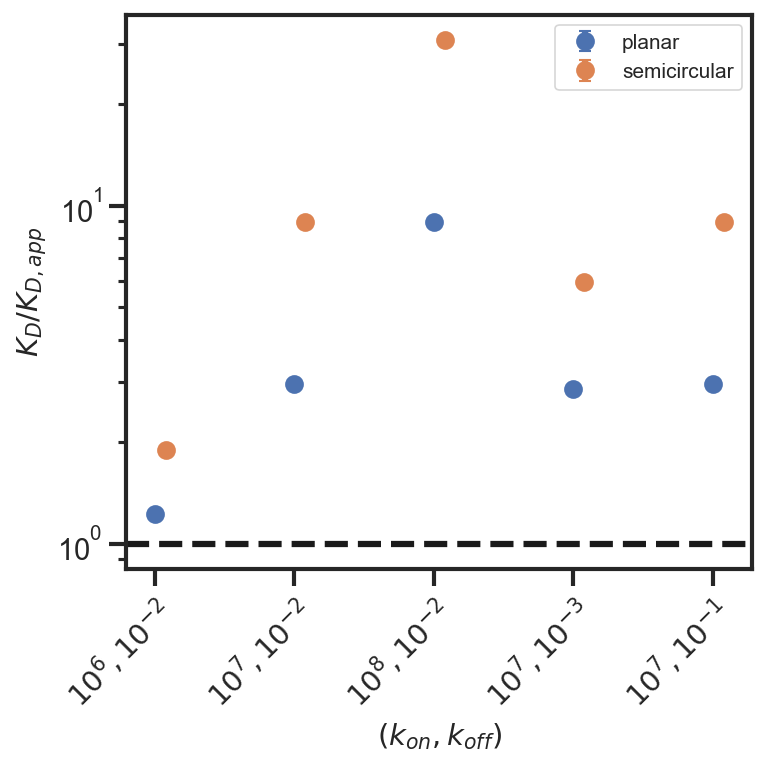

In [8]:
kinetic["geometry"] = np.where(kinetic.curvature_m_inv.fillna(0).eq(0),"planar","semicircular")
summary=condition_statistics(kinetic,["k_on_M_inv_s","k_off_s","geometry"],["affinity_shift_fold"])
fig,ax=plt.subplots(figsize=(5,5),constrained_layout=True)
for geometry,frame in summary.groupby("geometry"):
 labels=[rf"$10^{{{int(np.log10(kon))}}},10^{{{int(np.log10(koff))}}}$" for kon,koff in zip(frame.k_on_M_inv_s,frame.k_off_s)]
 x=np.arange(len(frame)); ax.errorbar(x+(0 if geometry=="planar" else .08),frame.affinity_shift_fold_mean,yerr=frame.affinity_shift_fold_sem,marker="o",ls="none",capsize=3,label=geometry)
ax.axhline(1,color="k",ls="--"); ax.set_xticks(np.arange(len(labels)),labels,rotation=45,ha="right",rotation_mode="anchor"); ax.set(yscale="log",xlabel=r"$(k_{on}, k_{off})$",ylabel=r"$K_D/K_{D,app}$")
ax.legend();
if SAVE_FIGURES: save_figure(fig,FIGURE_ROOT,"supp_kinetic_robustness")
plt.show()


## 3. Sinusoidal height and escape-plane control


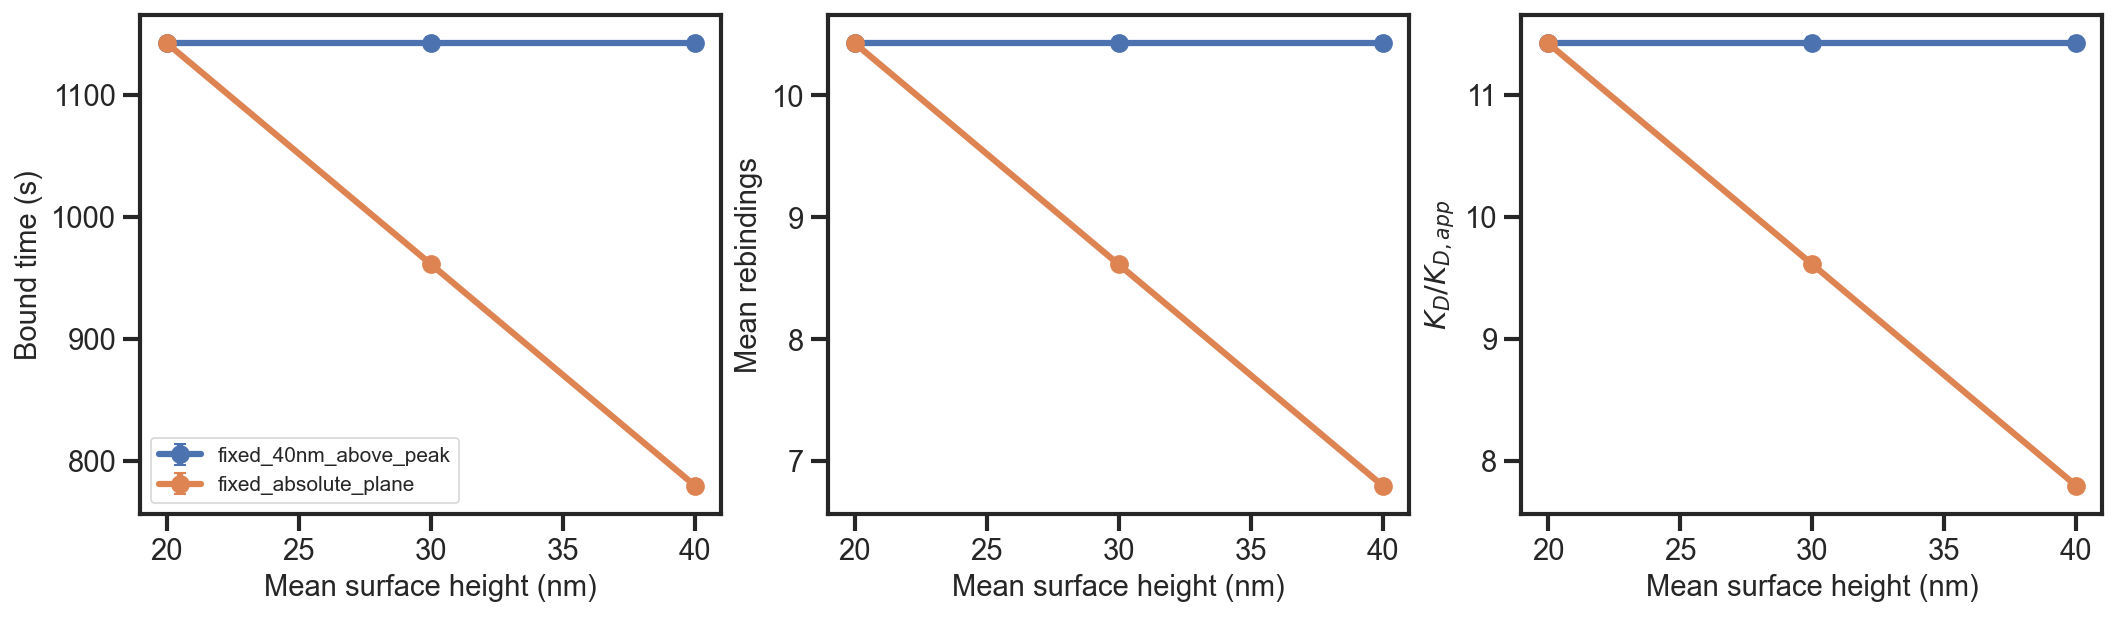

In [6]:
height["mean_z_nm"]=height.mean_z_m*1e9
stats_h=condition_statistics(height,["boundary_series","mean_z_nm"],["mean_bound_time_s","mean_rebindings","affinity_shift_fold"])
fig,axes=plt.subplots(1,3,figsize=(14,4),constrained_layout=True)
for series,frame in stats_h.groupby("boundary_series"):
 frame=frame.sort_values("mean_z_nm")
 for ax,metric in zip(axes,["mean_bound_time_s","mean_rebindings","affinity_shift_fold"]): ax.errorbar(frame.mean_z_nm,frame[f"{metric}_mean"],yerr=frame[f"{metric}_sem"],marker="o",capsize=3,label=series)
for ax,label in zip(axes,["Bound time (s)","Mean rebindings",r"$K_D/K_{D,app}$"]): ax.set(xlabel="Mean surface height (nm)",ylabel=label)
axes[0].legend()
if SAVE_FIGURES: save_figure(fig,FIGURE_ROOT,"supp_sinusoidal_height_control")
plt.show()
